####

## MR4010 Navegacion autonoma

### Deteccion de bordes

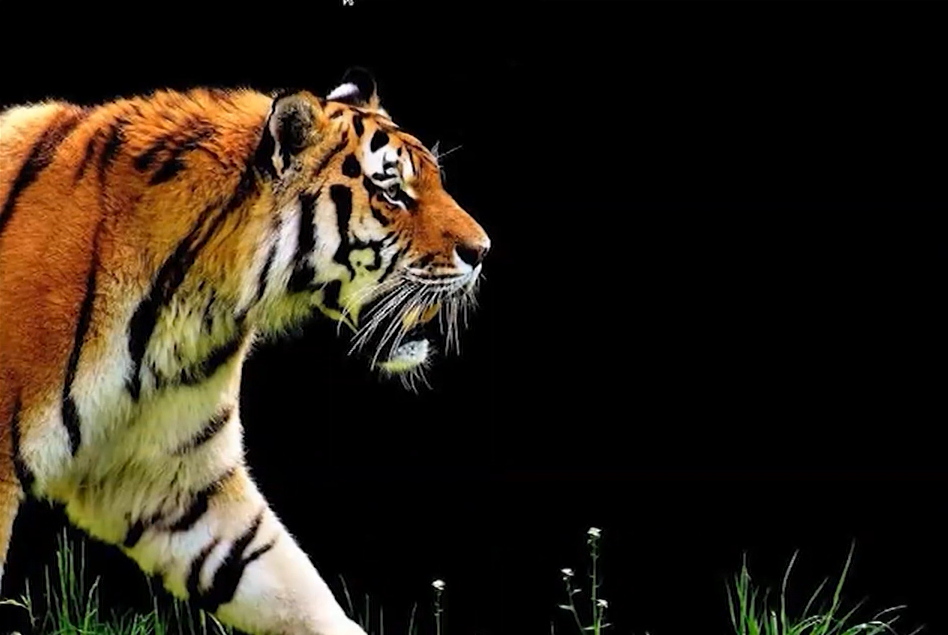

#### 1. Importar librerías

In [4]:
# Librerías básicas para procesamiento de imágenes
import numpy as np
import cv2

# Visualización
import matplotlib.pyplot as plt

# Para mostrar imágenes dentro del notebook
%matplotlib inline

#### 2. Función para mostrar imágenes

In [5]:
def display_img(img, title="Imagen"):
    """
    Muestra una imagen usando matplotlib
    - img: imagen en formato numpy array
    - title: título opcional
    """
    plt.figure(figsize=(8,6))
    plt.imshow(img, cmap='gray')  # usamos escala de grises
    plt.title(title)
    plt.axis('off')

#### 3. Cargar imagen en escala de grises

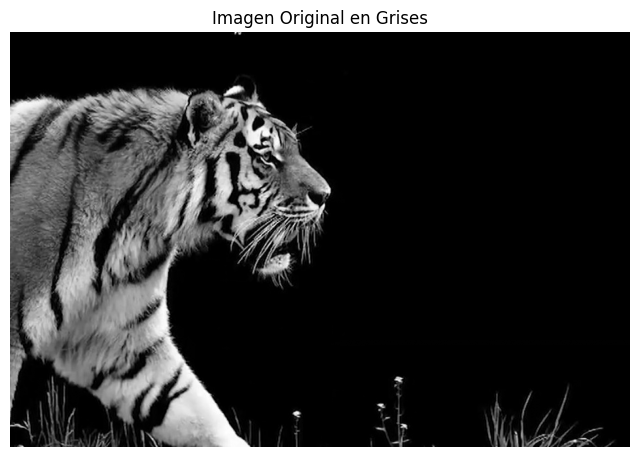

In [6]:
# NOTA: Cambia el nombre por tu imagen
img = cv2.imread('D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\Module1\Screenshot_tiger.jpg', cv2.IMREAD_GRAYSCALE)

display_img(img, "Imagen Original en Grises")

📌 Nota importante:

La detección de bordes funciona mejor en escala de grises

Reduce complejidad (1 canal en lugar de 3)

#### 4. Aplicar filtro Gaussiano (eliminar ruido)

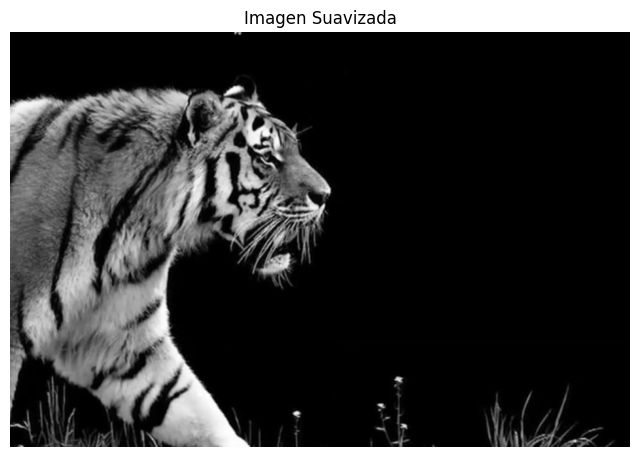

In [7]:
# Aplicamos un blur para suavizar la imagen
# (kernel debe ser impar: 3x3, 5x5, etc.)
img_blur = cv2.GaussianBlur(img, (3,3), sigmaX=0, sigmaY=0)

display_img(img_blur, "Imagen Suavizada")

📌 Nota:

Reduce ruido

Mejora detección de bordes

Evita falsos positivos

#### 5. Detección de bordes con Sobel (Eje X)

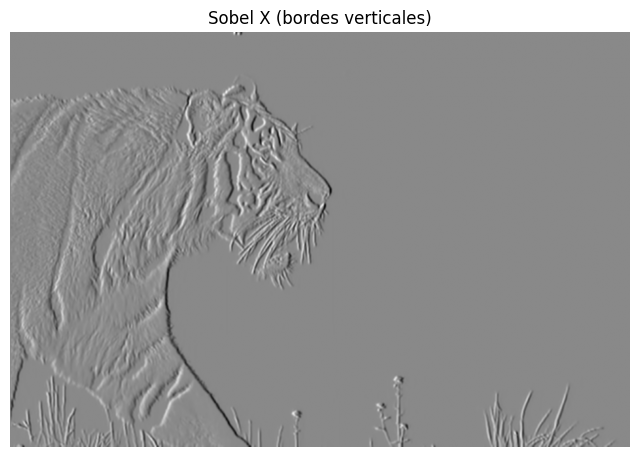

In [8]:
# Detecta cambios horizontales (bordes verticales)
sobel_x = cv2.Sobel(
    src=img_blur,
    ddepth=cv2.CV_64F,
    dx=1,  # derivada en X
    dy=0,
    ksize=5
)

display_img(sobel_x, "Sobel X (bordes verticales)")

#### 6. Sobel (Eje Y)

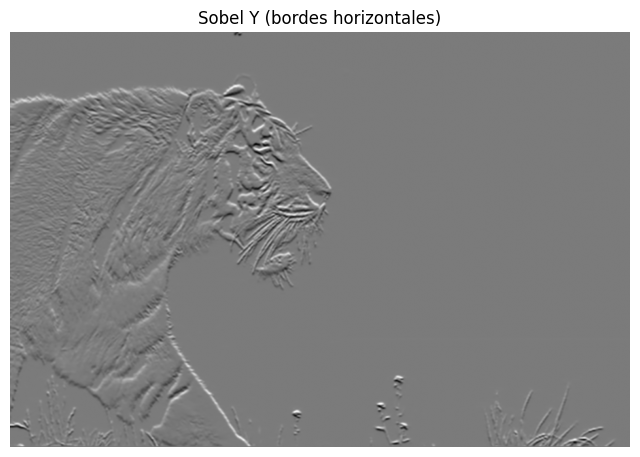

In [9]:
# Detecta cambios verticales (bordes horizontales)
sobel_y = cv2.Sobel(
    src=img_blur,
    ddepth=cv2.CV_64F,
    dx=0,
    dy=1,  # derivada en Y
    ksize=5
)

display_img(sobel_y, "Sobel Y (bordes horizontales)")

#### 7. Sobel combinado (X + Y)

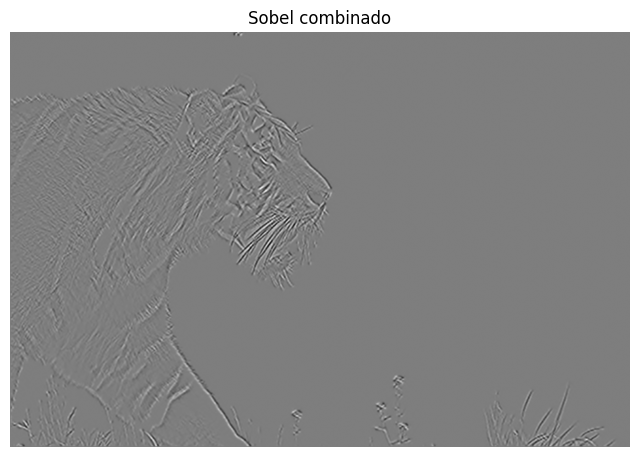

In [10]:
# Detecta bordes en ambas direcciones
sobel_xy = cv2.Sobel(
    src=img_blur,
    ddepth=cv2.CV_64F,
    dx=1,
    dy=1,
    ksize=5
)

display_img(sobel_xy, "Sobel combinado")

📌 Nota:

Sobel = primera derivada

Detecta cambios de intensidad

#### 8. Método Laplaciano (segunda derivada)

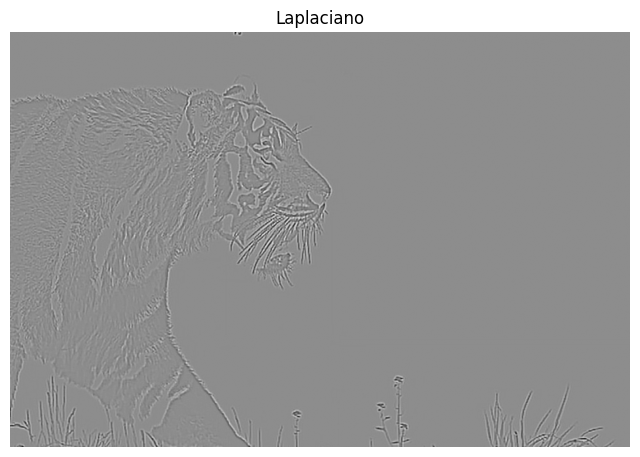

In [11]:
# Detecta bordes usando segunda derivada
laplacian = cv2.Laplacian(
    src=img_blur,
    ddepth=cv2.CV_64F,
    ksize=3
)

display_img(laplacian, "Laplaciano")

📌 Nota:

Más sensible al ruido

Detecta cambios bruscos (curvatura)

#### 9. Método Canny (el más usado)

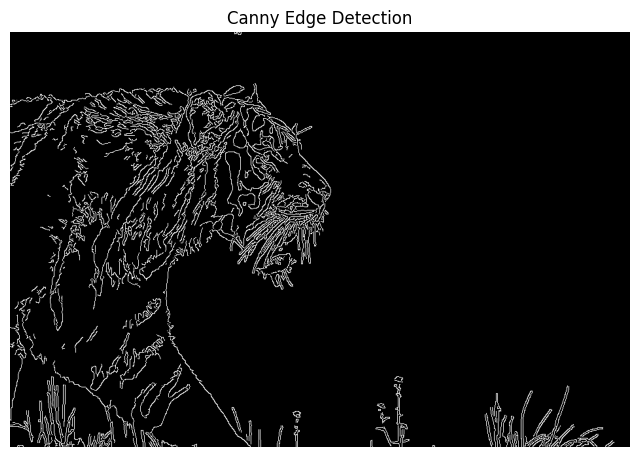

In [12]:
# Detector de bordes más robusto
canny = cv2.Canny(
    image=img_blur,
    threshold1=100,
    threshold2=200
)

display_img(canny, "Canny Edge Detection")

🧠 ¿Cómo funciona Canny?

Reducción de ruido (Gaussian Blur)

Cálculo de gradiente

Supresión de no-máximos

Umbralización con histéresis

📌 Tip importante:

threshold1 = límite bajo

threshold2 = límite alto

#### Bonus: Comparación rápida

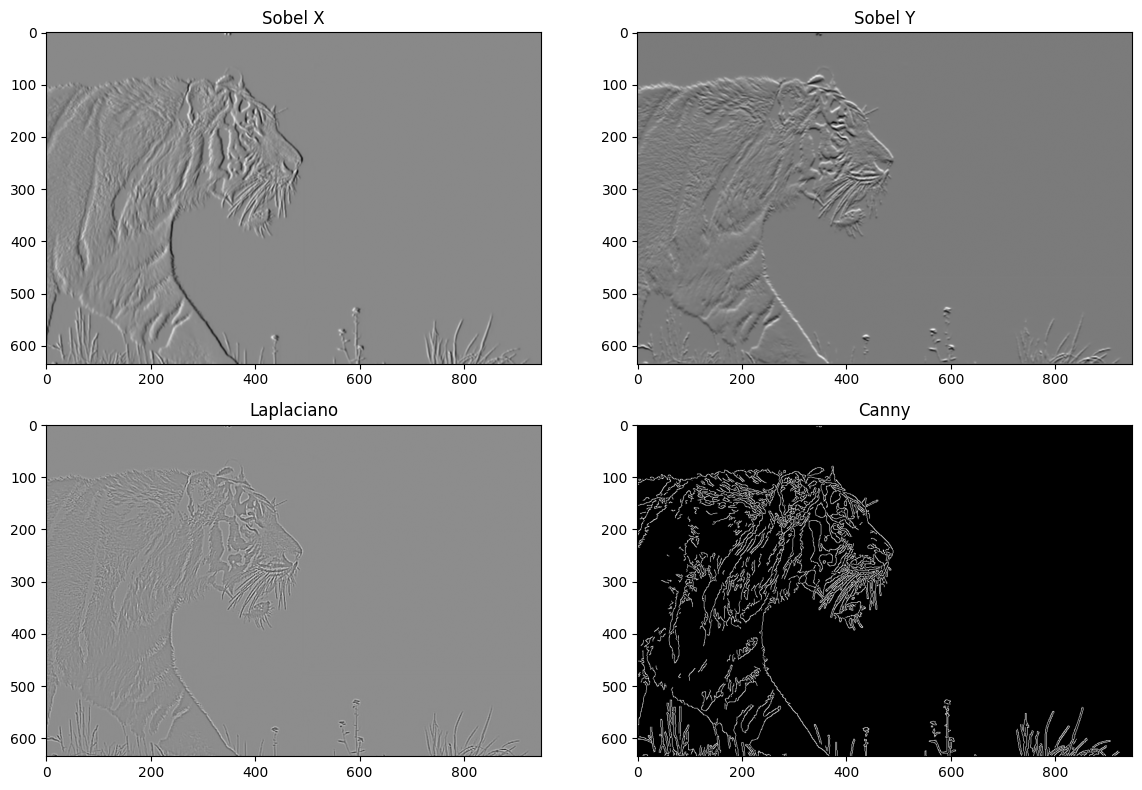

In [13]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(sobel_x, cmap='gray')
plt.title("Sobel X")

plt.subplot(2,2,2)
plt.imshow(sobel_y, cmap='gray')
plt.title("Sobel Y")

plt.subplot(2,2,3)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplaciano")

plt.subplot(2,2,4)
plt.imshow(canny, cmap='gray')
plt.title("Canny")

plt.tight_layout()
plt.show()

🚀 Notas para tu clase (clave para examen)

Sobel → dirección de bordes

Laplaciano → intensidad del cambio

Canny → pipeline completo (mejor precisión)

Gaussian Blur → obligatorio antes